In [ ]:
print(" hello")

 hello


### Data Collection and Presentation

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style='whitegrid')


zomato_df = pd.read_csv("Zomato-data-.csv")

zomato_df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


Data Collection and Presentation

In [ ]:
zomato_df.shape
zomato_df['rate'].unique()



array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

In [ ]:

zomato_df['rate'] = zomato_df['rate'].astype(str)

zomato_df['rate'] = zomato_df['rate'].str.replace('/5','', regex=False)



zomato_df['rate'] = zomato_df['rate'].replace(['NEW', ' -', 'nan'],np.nan)

zomato_df['rate'] = zomato_df['rate'].astype(float)


In [ ]:
zomato_df.isnull().sum()


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


# **Exploratory Data Analysis**

/tmp/ipykernel_234/2329048133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zomato_df, y='listed_in(type)' ,order=zomato_df['listed_in(type)'].value_counts().index, palette='Set2')


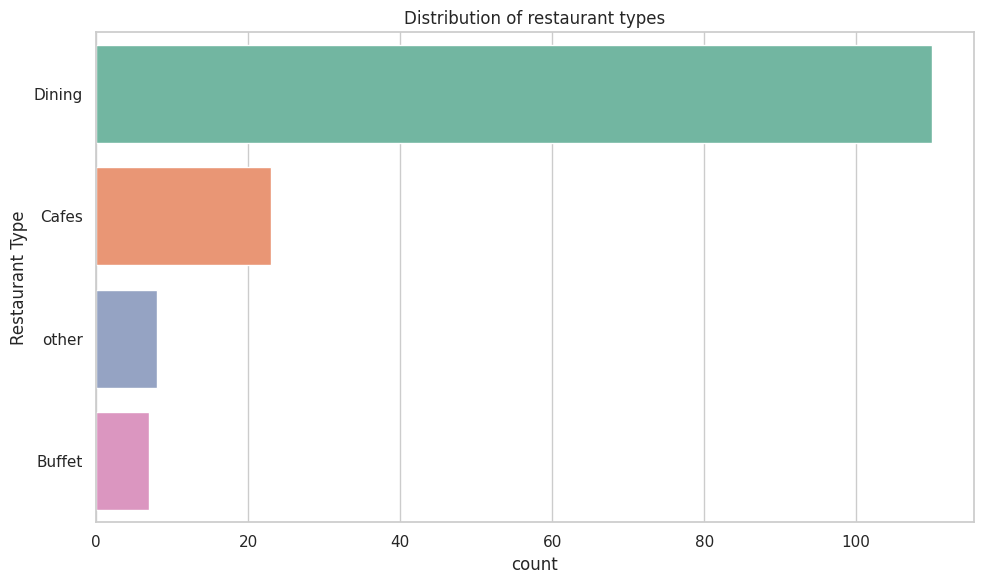

In [ ]:
# what type of restaurant is most common

plt.figure(figsize=(10,6))
sns.countplot(data=zomato_df, y='listed_in(type)' ,order=zomato_df['listed_in(type)'].value_counts().index, palette='Set2')

plt.title('Distribution of restaurant types')
plt.xlabel('count')
plt.ylabel('Restaurant Type')
plt.tight_layout()
plt.show()

/tmp/ipykernel_234/863507762.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=votes_by_type.values,y=votes_by_type.index,palette='coolwarm')


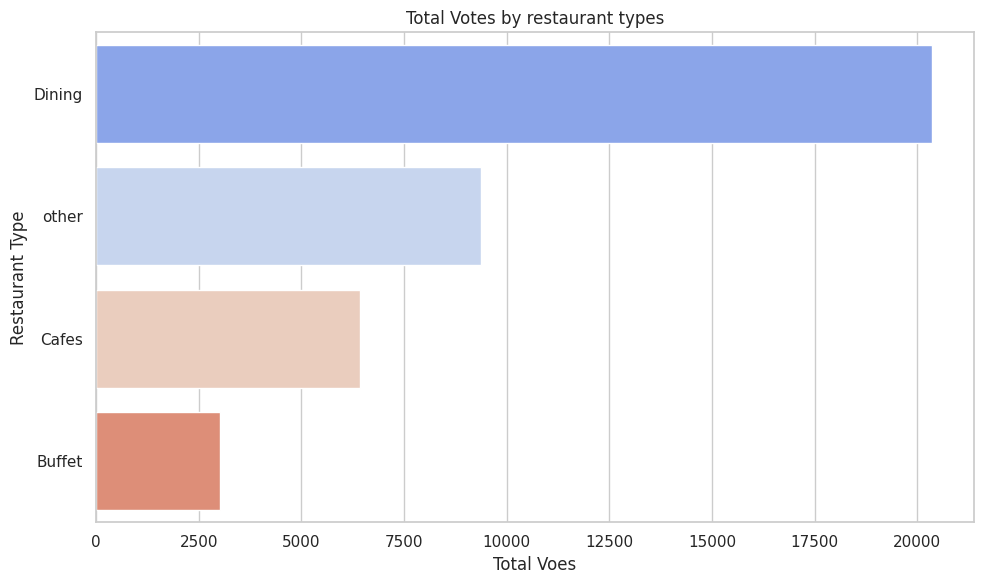

In [ ]:
# how many votes has each type of restaurant has received

plt.figure(figsize=(10,6))
votes_by_type = zomato_df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False)
sns.barplot(x=votes_by_type.values,y=votes_by_type.index,palette='coolwarm')
plt.title('Total Votes by restaurant types')
plt.xlabel('Total Voes')
plt.ylabel('Restaurant Type')
plt.tight_layout()
plt.show()

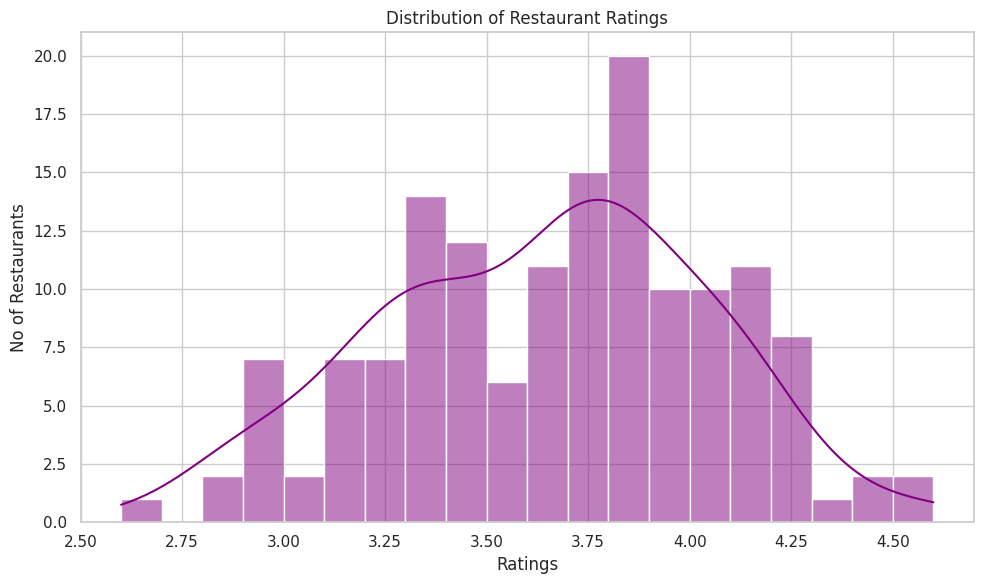

In [ ]:
# what is the most common rating range

plt.figure(figsize=(10,6))
sns.histplot(zomato_df['rate'],bins=20,kde=True,color='purple')

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Ratings')
plt.ylabel('No of Restaurants')
plt.tight_layout()
plt.show()

/tmp/ipykernel_234/1978713039.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zomato_df, x='approx_cost(for two people)', order = zomato_df['approx_cost(for two people)'].value_counts().index[:15],palette='Set1')


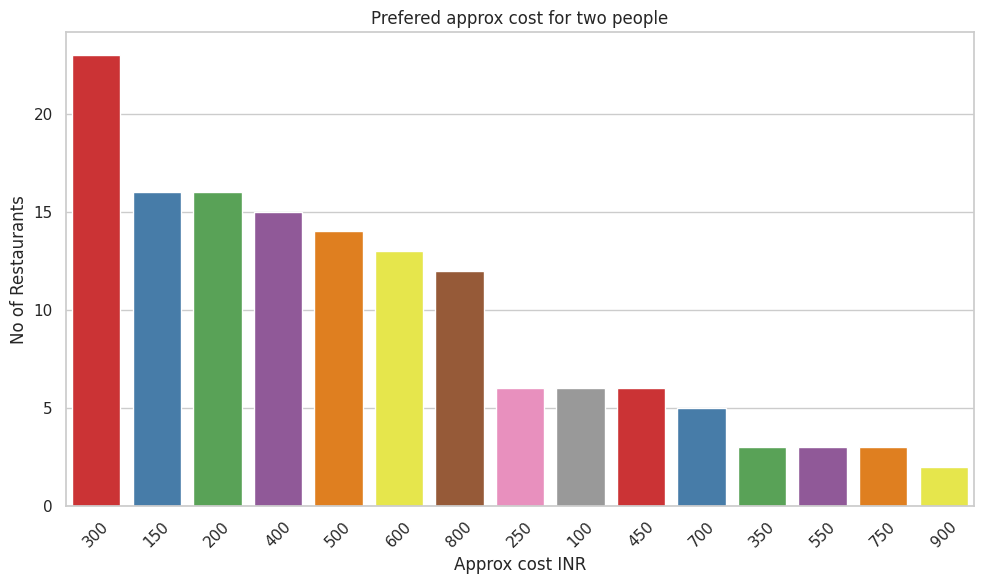

In [ ]:
# what is the  spending preference of couples (approximate cost for two) ?

plt.figure(figsize=(10,6))
sns.countplot(data=zomato_df, x='approx_cost(for two people)', order = zomato_df['approx_cost(for two people)'].value_counts().index[:15],palette='Set1')

plt.xticks(rotation=45)
plt.title('Prefered approx cost for two people')
plt.xlabel('Approx cost INR')
plt.ylabel('No of Restaurants')
plt.tight_layout()
plt.show()

/tmp/ipykernel_234/2721352899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=zomato_df, x='online_order', y='rate',palette='coolwarm')


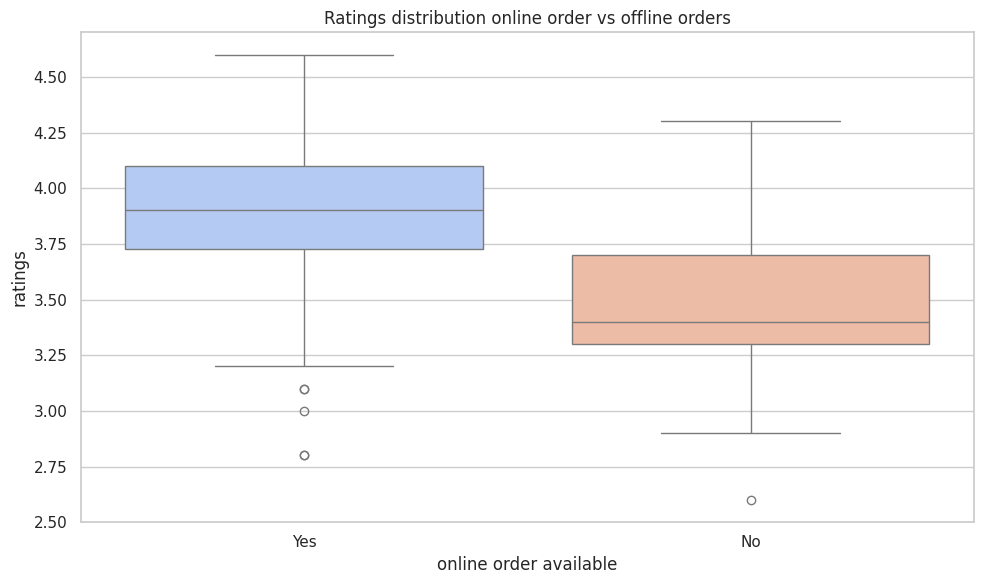

In [ ]:
# do restaurant that accept online orders receive better response than thos they dont

plt.figure(figsize=(10,6))
sns.boxplot(data=zomato_df, x='online_order', y='rate',palette='coolwarm')

plt.title('Ratings distribution online order vs offline orders')
plt.xlabel('online order available')
plt.ylabel('ratings')
plt.tight_layout()
plt.show()

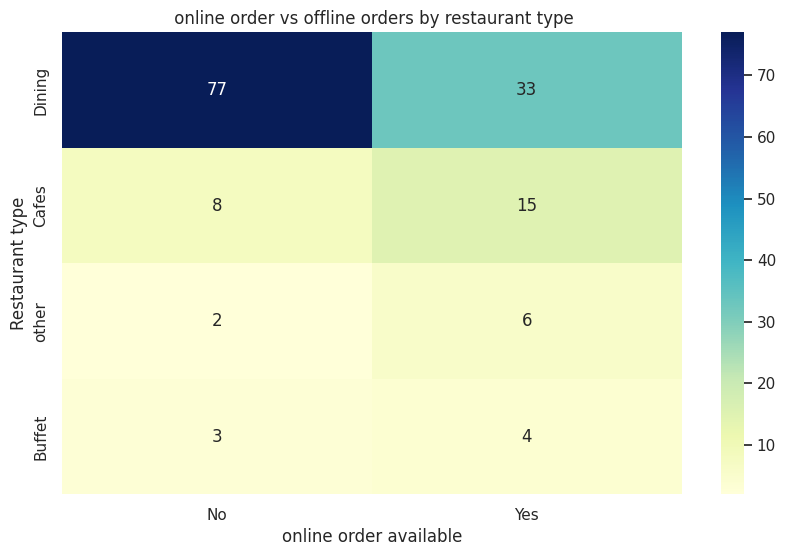

In [ ]:
# which restaurant type are more likely to offers online orders and which lean offline orders

pivot_table=pd.pivot_table(zomato_df,index='listed_in(type)',columns='online_order',values='name',aggfunc='count', fill_value=0)
pivot_table_sorted=pivot_table.sort_values(by='Yes',ascending=False)


plt.figure(figsize=(10,6))
sns.heatmap(pivot_table_sorted, annot=True,fmt='d',cmap='YlGnBu')


plt.title(' online order vs offline orders by restaurant type')
plt.xlabel('online order available')
plt.ylabel('Restaurant type')

plt.show()

In [ ]:
zomato_df['votes'].unique()


zomato_df['votes'] = zomato_df['votes'].astype(float)

df['approx_cost(for two people)'].unique()